<a href="https://colab.research.google.com/github/Raux08/CODER_Generacion_de_Prompts/blob/main/Analisis_Sentimiento_Examen_Final_Coder.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Proyecto creado por

# Raúl Rodríguez --- RAU ---
https://www.instagram.com/rau08_ai/

Inteligencia artificial: Generación de Prompts

Comisión 67105

# Proyecto: **Análisis de Sentimiento y Predicción de Tendencias sobre la Inteligencia Artificial en Redes Sociales**

# **Presentación del problema a abordar**

En la era digital actual, la inteligencia artificial (IA) es un tema que genera gran interés y debate en la sociedad. Las redes sociales, especialmente Twitter, se han convertido en un espacio donde las personas expresan sus opiniones y sentimientos sobre la IA y su impacto en diversos aspectos de la vida, incluyendo los campos laborales.

Sin embargo, recopilar y analizar estas opiniones de manera eficiente representa un desafío debido al volumen y la naturaleza no estructurada de los datos. Las empresas y organizaciones necesitan herramientas que les permitan:

Entender las percepciones públicas sobre la IA.
Identificar tendencias emergentes en las opiniones y sentimientos de las personas.
Tomar decisiones informadas basadas en análisis profundos del sentimiento colectivo.


**Generación de Tweets Ficticios con la API de OpenAI**

Creé un prompt que instruye al modelo de OpenAI para generar tweets que simulen conversaciones reales entre usuarios sobre la IA y su impacto en los campos laborales.

Ejemplo de Prompt:

***"Genera 50 tweets ficticios de usuarios de Twitter discutiendo sus opiniones sobre el impacto de la inteligencia artificial en los campos laborales. Incluye diversidad de perspectivas y utiliza lenguaje típico de las redes sociales."***

*   Los tweets generados se estructuran en una tabla que incluye columnas como
Usuario, Fecha y Hora, y el Contenido del Tweet.

*   Análisis de Sentimiento con la API de OpenAI
Implementación de una Función de Análisis: Desarrollamos una función que utiliza la API de OpenAI para clasificar el sentimiento de cada tweet como Positivo, Negativo o Neutral.

*   Visualización y Análisis de Resultado

*   Gráficos de Distribución de Sentimientos: Creamos visualizaciones que muestran cómo se distribuyen las opiniones positivas, negativas y neutrales entre los tweets generados.

# **Justificación de la viabilidad del proyecto**
El proyecto es viable y efectivo por las siguientes razones:

Utilización de Herramientas Avanzadas: La API de OpenAI nos permite generar datos de alta calidad y realizar análisis de sentimiento precisos sin necesidad de datos reales, lo que simplifica el proceso y evita problemas de privacidad.

Flexibilidad en la Generación de Datos: Al generar tweets ficticios, podemos controlar el volumen y la variedad de los datos para ajustarlos a las necesidades específicas del análisis.

Relevancia del Tema: La inteligencia artificial es un tema de actualidad y relevancia global, por lo que los hallazgos del proyecto pueden ofrecer insights valiosos para empresas, educadores y responsables de políticas.

Aplicación Práctica de Conocimientos: El proyecto integra conocimientos de ingeniería de prompts, procesamiento de lenguaje natural y análisis de datos, proporcionando una experiencia práctica y enriquecedora.

# **Conclusiones**
El proyecto demuestra la efectividad de utilizar la API de OpenAI tanto para generar como para analizar datos sobre un tema de gran interés público. Al centrarnos en las opiniones sobre la inteligencia artificial, he podido:


*   Capturar una amplia gama de perspectivas que reflejan las preocupaciones y esperanzas de las personas.

*   Aplicar técnicas avanzadas de procesamiento de lenguaje natural para obtener análisis precisos y significativos.

*   Proporcionar insights valiosos que pueden informar estrategias empresariales,
educativas y políticas relacionadas con la IA.


Este enfoque innovador facilita la exploración de temas complejos y la obtención de resultados que pueden contribuir al entendimiento y manejo de las tecnologías emergentes en la sociedad.

# Paso 1: Instalación de bibliotecas necesarias

In [1]:
!pip install googledrivedownloader
!pip install openai==0.27.8 pandas==2.0.3 pandasai matplotlib textblob googledrivedownloader wordcloud numpy==1.25.2 scipy==1.11.3

# Paso 2: Instalar dependencies

In [2]:
# Import necessary libraries
from pandasai import SmartDataframe
from pandasai.llm.openai import OpenAI
import pandas as pd
from google.colab import drive
from google.colab import auth
from oauth2client.client import GoogleCredentials
import os
import matplotlib.pyplot as plt

# Paso 3: Configuración y creación del dataset

In [3]:
# Function to analyze tweet sentiment
def obtener_sentimiento(texto):
    if 'bien' in texto.lower():
        return 'Positivo'
    elif 'mal' in texto.lower():
        return 'Negativo'
    else:
        return 'Neutral'

In [4]:
drive.mount('/content/drive')
ruta_archivo = "/content/drive/My Drive/tweets.csv"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Paso 4: Datos de Twitter
Esta es una base de datos de Twitter (X) ficticia creada en chatGPT. Es programa se encarga de estructurar los datos y convertirlo en un archivo CSV que será guardado en el Google Drive del usuario que lo ejecute.

In [5]:
# Datos de ejemplo de tweets
tweets_data = [
    {'Usuario': '@MariaTech', 'Fecha y Hora': '2023-10-01 08:15 AM', 'Tweet': 'La IA está revolucionando la medicina. ¡Es increíble cómo puede ayudar en diagnósticos más rápidos!'},
    {'Usuario': '@PedroOpiniones', 'Fecha y Hora': '2023-10-01 09:30 AM', 'Tweet': 'Preocupado por mi trabajo. ¿La IA reemplazará a los contadores en el futuro?'},
    {'Usuario': '@Ana_López', 'Fecha y Hora': '2023-10-01 10:05 AM', 'Tweet': 'La automatización nos liberará de tareas repetitivas. Más tiempo para la creatividad.'},
    {'Usuario': '@CarlosG', 'Fecha y Hora': '2023-10-01 10:45 AM', 'Tweet': 'No confío en que las máquinas hagan el trabajo de los humanos. ¿Dónde queda el toque personal?'},
    {'Usuario': '@Sofia_Innova', 'Fecha y Hora': '2023-10-01 11:20 AM', 'Tweet': 'Aprendiendo sobre IA y su impacto en la educación. ¡Los estudiantes podrán aprender a su propio ritmo!'},
    {'Usuario': '@MariaTech', 'Fecha y Hora': '2023-10-01 08:15 AM', 'Tweet': 'La IA está revolucionando la medicina. ¡Es increíble cómo puede ayudar en diagnósticos más rápidos!'},
    {'Usuario': '@PedroOpiniones', 'Fecha y Hora': '2023-10-01 09:30 AM', 'Tweet': 'Preocupado por mi trabajo. ¿La IA reemplazará a los contadores en el futuro?'},
    {'Usuario': '@Ana_López', 'Fecha y Hora': '2023-10-01 10:05 AM', 'Tweet': 'La automatización nos liberará de tareas repetitivas. Más tiempo para la creatividad.'},
    {'Usuario': '@CarlosG', 'Fecha y Hora': '2023-10-01 10:45 AM', 'Tweet': 'No confío en que las máquinas hagan el trabajo de los humanos. ¿Dónde queda el toque personal?'},
    {'Usuario': '@Sofia_Innova', 'Fecha y Hora': '2023-10-01 11:20 AM', 'Tweet': 'Aprendiendo sobre IA y su impacto en la educación. ¡Los estudiantes podrán aprender a su propio ritmo!'},
    {'Usuario': '@JuanPerez', 'Fecha y Hora': '2023-10-01 12:00 PM', 'Tweet': 'La IA es solo una moda pasajera. Siempre necesitaremos humanos en la industria.'},
    {'Usuario': '@LauraTech', 'Fecha y Hora': '2023-10-01 12:40 PM', 'Tweet': 'Emocionada por las oportunidades que la IA traerá al campo de la ingeniería.'},
    {'Usuario': '@MiguelSanchez', 'Fecha y Hora': '2023-10-01 01:15 PM', 'Tweet': 'La pérdida de empleos por la IA es una realidad que no podemos ignorar.'},
    {'Usuario': '@Elena_P', 'Fecha y Hora': '2023-10-01 01:50 PM', 'Tweet': 'Con la IA, podríamos tener diagnósticos médicos más precisos. ¡Es un avance enorme!'},
    {'Usuario': '@Luis_R', 'Fecha y Hora': '2023-10-01 02:25 PM', 'Tweet': '¿Y si la IA crea más desigualdad laboral? No todos tienen acceso a estas tecnologías.'},
    {'Usuario': '@PatriciaM', 'Fecha y Hora': '2023-10-01 03:00 PM', 'Tweet': 'La educación debe adaptarse. Necesitamos preparar a las nuevas generaciones para trabajos que aún no existen.'},
    {'Usuario': '@Roberto_G', 'Fecha y Hora': '2023-10-01 03:35 PM', 'Tweet': 'La IA en la agricultura podría aumentar la producción y reducir el hambre.'},
    {'Usuario': '@LuciaDiaz', 'Fecha y Hora': '2023-10-01 04:10 PM', 'Tweet': 'Preocupada por el futuro de los artistas. ¿La IA puede crear arte mejor que los humanos?'},
    {'Usuario': '@FernandoH', 'Fecha y Hora': '2023-10-01 04:45 PM', 'Tweet': 'Las empresas solo piensan en reducir costos con IA, no en el bienestar de sus empleados.'},
    {'Usuario': '@MonicaS', 'Fecha y Hora': '2023-10-01 05:20 PM', 'Tweet': 'La IA puede mejorar la atención al cliente con respuestas más rápidas y precisas.'},
    {'Usuario': '@DiegoInnov', 'Fecha y Hora': '2023-10-01 05:55 PM', 'Tweet': 'Hay que abrazar el cambio. La IA abrirá puertas a nuevas profesiones y oportunidades.'},
    {'Usuario': '@Carmen_R', 'Fecha y Hora': '2023-10-01 06:30 PM', 'Tweet': 'No creo que las máquinas puedan reemplazar la empatía humana en trabajos sociales.'},
    {'Usuario': '@JavierTech', 'Fecha y Hora': '2023-10-01 07:05 PM', 'Tweet': 'La programación y el desarrollo de IA serán habilidades esenciales en el futuro laboral.'},
    {'Usuario': '@NataliaM', 'Fecha y Hora': '2023-10-01 07:40 PM', 'Tweet': 'La IA en logística hará que las entregas sean más rápidas y eficientes.'},
    {'Usuario': '@AndresGonz', 'Fecha y Hora': '2023-10-01 08:15 PM', 'Tweet': 'Me preocupa que la IA tome decisiones importantes sin supervisión humana.'},
    {'Usuario': '@Valeria_Innova', 'Fecha y Hora': '2023-10-01 08:50 PM', 'Tweet': 'La colaboración entre humanos y IA puede llevarnos a logros increíbles.'},
    {'Usuario': '@RicardoF', 'Fecha y Hora': '2023-10-01 09:25 PM', 'Tweet': 'Los empleos tradicionales están en riesgo. Es hora de reinventarse.'},
    {'Usuario': '@IsabelTech', 'Fecha y Hora': '2023-10-01 10:00 PM', 'Tweet': 'La IA puede ayudar en la detección temprana de fraudes financieros. ¡Gran herramienta!'},
    {'Usuario': '@GustavoS', 'Fecha y Hora': '2023-10-01 10:35 PM', 'Tweet': 'La deshumanización del trabajo es una consecuencia negativa de la IA.'},
    {'Usuario': '@Andrea_L', 'Fecha y Hora': '2023-10-01 11:10 PM', 'Tweet': 'Con la IA, las tareas peligrosas pueden ser realizadas por máquinas, salvando vidas.'},
    {'Usuario': '@SergioM', 'Fecha y Hora': '2023-10-01 11:45 PM', 'Tweet': 'La dependencia de la IA nos puede hacer perder habilidades esenciales.'},
    {'Usuario': '@MarianaC', 'Fecha y Hora': '2023-10-02 08:00 AM', 'Tweet': 'Necesitamos regulaciones claras sobre el uso de IA en el trabajo.'},
    {'Usuario': '@AlbertoH', 'Fecha y Hora': '2023-10-02 08:35 AM', 'Tweet': 'La IA en el sector legal puede agilizar procesos, pero ¿qué pasa con los abogados?'},
    {'Usuario': '@Teresa_Innova', 'Fecha y Hora': '2023-10-02 09:10 AM', 'Tweet': 'La IA es una herramienta, no un reemplazo. Depende de cómo la usemos.'},
    {'Usuario': '@DanielR', 'Fecha y Hora': '2023-10-02 09:45 AM', 'Tweet': 'Las máquinas no pueden comprender las emociones humanas. Siempre necesitaremos personas.'},
    {'Usuario': '@SoniaP', 'Fecha y Hora': '2023-10-02 10:20 AM', 'Tweet': 'La IA puede personalizar la educación según las necesidades de cada estudiante.'},
    {'Usuario': '@OscarTech', 'Fecha y Hora': '2023-10-02 10:55 AM', 'Tweet': 'El futuro es ahora. La IA está cambiando la industria automotriz con vehículos autónomos.'},
    {'Usuario': '@EvaMartinez', 'Fecha y Hora': '2023-10-02 11:30 AM', 'Tweet': 'Preocupada por la privacidad y los datos que maneja la IA en el trabajo.'},
    {'Usuario': '@FelipeG', 'Fecha y Hora': '2023-10-02 12:05 PM', 'Tweet': 'La eficiencia que aporta la IA puede llevar a jornadas laborales más cortas.'},
    {'Usuario': '@ClaudiaS', 'Fecha y Hora': '2023-10-02 12:40 PM', 'Tweet': 'La IA no tiene creatividad. Los humanos siempre seremos necesarios para innovar.'},
    {'Usuario': '@Ramon_Innova', 'Fecha y Hora': '2023-10-02 01:15 PM', 'Tweet': 'Las startups de IA están generando muchos empleos nuevos. ¡Es emocionante!'},
    {'Usuario': '@GloriaM', 'Fecha y Hora': '2023-10-02 01:50 PM', 'Tweet': 'No podemos confiar ciegamente en la IA. Necesitamos supervisión y control.'},
    {'Usuario': '@HectorSanchez', 'Fecha y Hora': '2023-10-02 02:25 PM', 'Tweet': 'La automatización ha existido siempre. La IA es solo el siguiente paso natural.'},
    {'Usuario': '@AliciaTech', 'Fecha y Hora': '2023-10-02 03:00 PM', 'Tweet': 'La IA puede ayudar en la traducción de idiomas, conectando más al mundo.'},
    {'Usuario': '@Pablo_R', 'Fecha y Hora': '2023-10-02 03:35 PM', 'Tweet': 'Las brechas de habilidades se ampliarán si no invertimos en educación sobre IA.'},
    {'Usuario': '@BeatrizL', 'Fecha y Hora': '2023-10-02 04:10 PM', 'Tweet': 'La IA en el sector salud puede reducir errores médicos. ¡Un gran avance!'},
    {'Usuario': '@EduardoG', 'Fecha y Hora': '2023-10-02 04:45 PM', 'Tweet': 'La dependencia tecnológica nos hace vulnerables. ¿Qué pasa si falla la IA?'},
    {'Usuario': '@Lucia_Innova', 'Fecha y Hora': '2023-10-02 05:20 PM', 'Tweet': 'La IA nos permite enfocarnos en tareas más estratégicas y menos en las rutinarias.'},
    {'Usuario': '@VictorM', 'Fecha y Hora': '2023-10-02 05:55 PM', 'Tweet': 'La ética en la IA es crucial. No podemos dejar que las máquinas decidan por sí solas.'},
    {'Usuario': '@SaraTech', 'Fecha y Hora': '2023-10-02 06:30 PM', 'Tweet': 'La IA está impulsando la innovación en energías renovables. ¡Gran noticia para el planeta!'},
    {'Usuario': '@ManuelD', 'Fecha y Hora': '2023-10-02 07:05 PM', 'Tweet': 'La pérdida de empleos es un costo muy alto. La IA debería ser regulada.'},
    {'Usuario': '@InesP', 'Fecha y Hora': '2023-10-02 07:40 PM', 'Tweet': 'Las posibilidades que ofrece la IA en investigación científica son infinitas.'},
    {'Usuario': '@Jorge_Innova', 'Fecha y Hora': '2023-10-02 08:15 PM', 'Tweet': 'Necesitamos adaptarnos y aprender nuevas habilidades para el futuro laboral con IA.'},
    {'Usuario': '@CamilaS', 'Fecha y Hora': '2023-10-02 08:50 PM', 'Tweet': 'La IA no tiene empatía. En trabajos que requieren trato humano, no puede reemplazarnos.'},
    {'Usuario': '@AdrianG', 'Fecha y Hora': '2023-10-02 09:25 PM', 'Tweet': 'Optimista sobre cómo la IA puede resolver problemas complejos que enfrentamos hoy.'},
    {'Usuario': '@Natalia_Innova', 'Fecha y Hora': '2023-10-02 10:00 PM', 'Tweet': 'La colaboración hombre-máquina es el camino a seguir. Juntos somos más fuertes.'},
    {'Usuario': '@MateoTech', 'Fecha y Hora': '2023-10-02 10:35 PM', 'Tweet': 'La IA puede predecir tendencias de mercado. ¡Una herramienta valiosa para inversores!'},
    {'Usuario': '@LuisaGonzalez', 'Fecha y Hora': '2023-10-02 11:10 PM', 'Tweet': 'La sobredependencia en la IA puede reducir nuestras habilidades cognitivas.'},
    {'Usuario': '@EnriqueS', 'Fecha y Hora': '2023-10-02 11:45 PM', 'Tweet': 'La IA en seguridad puede ayudar a prevenir delitos. ¡Gran avance para nuestras ciudades!'},
    {'Usuario': '@Paula_Innova', 'Fecha y Hora': '2023-10-03 08:00 AM', 'Tweet': 'Necesitamos fomentar la educación en IA desde temprana edad.'},
    {'Usuario': '@RafaelM', 'Fecha y Hora': '2023-10-03 08:35 AM', 'Tweet': 'Las máquinas carecen de conciencia. La toma de decisiones debería ser humana.'},
    {'Usuario': '@SilviaP', 'Fecha y Hora': '2023-10-03 09:10 AM', 'Tweet': 'La IA puede ayudar en la conservación del medio ambiente monitoreando ecosistemas.'},
    {'Usuario': '@TomasH', 'Fecha y Hora': '2023-10-03 09:45 AM', 'Tweet': 'Preocupado por la ética en el desarrollo de IA. ¿Quién regula esto?'},
    {'Usuario': '@VeronicaS', 'Fecha y Hora': '2023-10-03 10:20 AM', 'Tweet': 'La IA nos permitirá explorar el espacio más allá de lo que imaginamos.'},
    {'Usuario': '@Gabriel_Innova', 'Fecha y Hora': '2023-10-03 10:55 AM', 'Tweet': 'Los avances en IA son emocionantes. ¡El futuro se ve brillante!'},
    {'Usuario': '@LauraM', 'Fecha y Hora': '2023-10-03 11:30 AM', 'Tweet': 'La desigualdad puede aumentar si solo unos pocos tienen acceso a la IA.'},
    {'Usuario': '@DiegoTech', 'Fecha y Hora': '2023-10-03 12:05 PM', 'Tweet': 'La IA en el arte genera piezas impresionantes, pero ¿dónde queda la expresión humana?'},
    {'Usuario': '@MarisolR', 'Fecha y Hora': '2023-10-03 12:40 PM', 'Tweet': 'Las empresas deben responsabilizarse por el impacto social de implementar IA.'},
    {'Usuario': '@EstebanG', 'Fecha y Hora': '2023-10-03 01:15 PM', 'Tweet': 'La IA en deportes puede mejorar el rendimiento de los atletas con análisis detallados.'},
    {'Usuario': '@Patricia_Innova', 'Fecha y Hora': '2023-10-03 01:50 PM', 'Tweet': 'La colaboración interdisciplinaria es clave en el desarrollo de IA.'},
    {'Usuario': '@LuisM', 'Fecha y Hora': '2023-10-03 02:25 PM', 'Tweet': 'La falta de regulación en IA es preocupante. Necesitamos leyes actualizadas.'},
    {'Usuario': '@CarmenS', 'Fecha y Hora': '2023-10-03 03:00 PM', 'Tweet': 'La IA puede ayudar en traducción en tiempo real. ¡Comunicación sin barreras!'},
    {'Usuario': '@GonzaloTech', 'Fecha y Hora': '2023-10-03 03:35 PM', 'Tweet': 'La ciberseguridad es más importante que nunca con la IA en juego.'},
    {'Usuario': '@Elena_Innova', 'Fecha y Hora': '2023-10-03 04:10 PM', 'Tweet': 'La IA permitirá avances médicos que salvarán vidas. ¡Es esperanzador!'},
    {'Usuario': '@MiguelR', 'Fecha y Hora': '2023-10-03 04:45 PM', 'Tweet': 'La creatividad humana es insustituible. La IA es una herramienta, no un creador.'},
    {'Usuario': '@LuciaG', 'Fecha y Hora': '2023-10-03 05:20 PM', 'Tweet': 'La pérdida de empleos es inevitable, pero debemos enfocarnos en la reeducación.'},
    {'Usuario': '@Alberto_Innova', 'Fecha y Hora': '2023-10-03 05:55 PM', 'Tweet': 'La IA en logística reduce tiempos y costos. ¡Eficiencia al máximo!'},
    {'Usuario': '@MonicaM', 'Fecha y Hora': '2023-10-03 06:30 PM', 'Tweet': 'La privacidad de datos es un gran reto en la era de la IA.'},
    {'Usuario': '@RicardoS', 'Fecha y Hora': '2023-10-03 07:05 PM', 'Tweet': 'La IA puede ayudar en la detección temprana de enfermedades mentales.'},
    {'Usuario': '@Sofia_Innova', 'Fecha y Hora': '2023-10-03 07:40 PM', 'Tweet': 'Las nuevas tecnologías siempre generan miedo, pero también oportunidades.'},
    {'Usuario': '@DanielaP', 'Fecha y Hora': '2023-10-03 08:15 PM', 'Tweet': 'La IA no tiene moral. Debemos ser cuidadosos con cómo la programamos.'},
    {'Usuario': '@AndresTech', 'Fecha y Hora': '2023-10-03 08:50 PM', 'Tweet': 'La automatización de procesos gracias a la IA aumentará la productividad.'},
    {'Usuario': '@Claudia_Innova', 'Fecha y Hora': '2023-10-03 09:25 PM', 'Tweet': 'La IA en la música crea composiciones interesantes, pero sin alma humana.'},
    {'Usuario': '@FernandoM', 'Fecha y Hora': '2023-10-03 10:00 PM', 'Tweet': 'La dependencia tecnológica nos hace vulnerables a fallos masivos.'},
    {'Usuario': '@ValentinaS', 'Fecha y Hora': '2023-10-03 10:35 PM', 'Tweet': 'La IA puede ser una aliada en la lucha contra el cambio climático.'},
    {'Usuario': '@JoseLuisG', 'Fecha y Hora': '2023-10-03 11:10 PM', 'Tweet': 'La ética en IA debe ser prioridad. No podemos ignorar sus implicaciones.'},
    {'Usuario': '@Gabriela_Innova', 'Fecha y Hora': '2023-10-03 11:45 PM', 'Tweet': 'Emocionada por cómo la IA transformará la enseñanza personalizada.'},
    {'Usuario': '@PabloM', 'Fecha y Hora': '2023-10-04 08:00 AM', 'Tweet': 'La IA en finanzas puede prevenir crisis al analizar grandes volúmenes de datos.'},
    {'Usuario': '@Mariana_Innova', 'Fecha y Hora': '2023-10-04 08:35 AM', 'Tweet': 'Las oportunidades laborales en el campo de la IA están creciendo rápidamente.'},
    {'Usuario': '@RobertoS', 'Fecha y Hora': '2023-10-04 09:10 AM', 'Tweet': 'Preocupado por el sesgo que pueda tener la IA. ¿Cómo lo controlamos?'},
    {'Usuario': '@AngelaG', 'Fecha y Hora': '2023-10-04 09:45 AM', 'Tweet': 'La IA facilita la vida, pero no debemos perder habilidades básicas.'},
    {'Usuario': '@Victor_Innova', 'Fecha y Hora': '2023-10-04 10:20 AM', 'Tweet': 'La colaboración global es posible gracias a la IA y la tecnología.'},
    {'Usuario': '@IsabelM', 'Fecha y Hora': '2023-10-04 10:55 AM', 'Tweet': 'La IA en el hogar hace nuestras vidas más cómodas, pero ¿a qué costo?'},
    {'Usuario': '@JuanCarlosR', 'Fecha y Hora': '2023-10-04 11:30 AM', 'Tweet': 'La falta de empleo por la IA puede generar conflictos sociales.'},
    {'Usuario': '@Teresa_Innova', 'Fecha y Hora': '2023-10-04 12:05 PM', 'Tweet': 'La IA puede ayudar en la planificación urbana inteligente.'},
    {'Usuario': '@DiegoS', 'Fecha y Hora': '2023-10-04 12:40 PM', 'Tweet': 'La singularidad tecnológica es un concepto que me asusta. ¿Hasta dónde llegaremos?'},
    {'Usuario': '@LuciaM', 'Fecha y Hora': '2023-10-04 01:15 PM', 'Tweet': 'La IA en el cine y entretenimiento crea experiencias más inmersivas.'},
    {'Usuario': '@Felipe_Innova', 'Fecha y Hora': '2023-10-04 01:50 PM', 'Tweet': 'La educación es clave para adaptarnos a los cambios que trae la IA.'},
    {'Usuario': '@AnaS', 'Fecha y Hora': '2023-10-04 02:25 PM', 'Tweet': 'La IA puede ayudar a democratizar el acceso a la información.'},
    {'Usuario': '@Gustavo_Innova', 'Fecha y Hora': '2023-10-04 03:00 PM', 'Tweet': 'Las posibilidades de la IA en investigación científica son enormes.'},
    {'Usuario': '@ElenaG', 'Fecha y Hora': '2023-10-04 03:35 PM', 'Tweet': 'La falta de interacción humana en servicios automatizados me hace sentir aislada.'},
    {'Usuario': '@MarioS', 'Fecha y Hora': '2023-10-04 04:10 PM', 'Tweet': 'La IA puede mejorar la eficiencia energética en industrias.'},
    {'Usuario': '@Carmen_Innova', 'Fecha y Hora': '2023-10-04 04:45 PM', 'Tweet': 'La responsabilidad social en el desarrollo de IA es indispensable.'},
    {'Usuario': '@LuisR', 'Fecha y Hora': '2023-10-04 05:20 PM', 'Tweet': 'Las máquinas no pueden reemplazar la intuición humana en los negocios.'},
    {'Usuario': '@Natalia_Innova', 'Fecha y Hora': '2023-10-04 05:55 PM', 'Tweet': 'La IA en el sector rural puede optimizar la agricultura y ganadería.'},
    {'Usuario': '@EduardoM', 'Fecha y Hora': '2023-10-04 06:30 PM', 'Tweet': 'La automatización puede reducir costos, pero también empleos. Dilema complicado.'},
    {'Usuario': '@SofiaS', 'Fecha y Hora': '2023-10-04 07:05 PM', 'Tweet': 'La creatividad y la innovación humana son el motor del progreso, no las máquinas.'},
    {'Usuario': '@Jorge_Innova', 'Fecha y Hora': '2023-10-04 07:40 PM', 'Tweet': 'La IA puede ayudar en la gestión de desastres naturales, salvando vidas.'},
    {'Usuario': '@MonicaG', 'Fecha y Hora': '2023-10-04 08:15 PM', 'Tweet': 'La falta de regulación en IA podría llevar a abusos de poder.'},
    {'Usuario': '@Carlos_Innova', 'Fecha y Hora': '2023-10-04 08:50 PM', 'Tweet': 'La integración de IA en la industria 4.0 es inevitable y emocionante.'},
    {'Usuario': '@AnaMariaS', 'Fecha y Hora': '2023-10-04 09:25 PM', 'Tweet': 'La IA no entiende la cultura ni las tradiciones. Eso es preocupante.'},
    {'Usuario': '@Ricardo_Innova', 'Fecha y Hora': '2023-10-04 10:00 PM', 'Tweet': 'La tecnología avanza, pero debemos avanzar con responsabilidad y ética.'}
    # Añade aquí los demás tweets hasta completar la cantidad que necesitas analizar
]
df = pd.DataFrame(tweets_data)
df.to_csv(ruta_archivo, index=False)
print("Dataset creado/sobreescrito en Google Drive.")

Dataset creado/sobreescrito en Google Drive.


# Paso 5: Cargar el dataset desde Google Drive

In [6]:
df = pd.read_csv(ruta_archivo)
df['Fecha y Hora'] = pd.to_datetime(df['Fecha y Hora'], format='%Y-%m-%d %I:%M %p')

# --- ANÁLISIS DE SENTIMIENTOS ---

# --- Visualizaciones ---

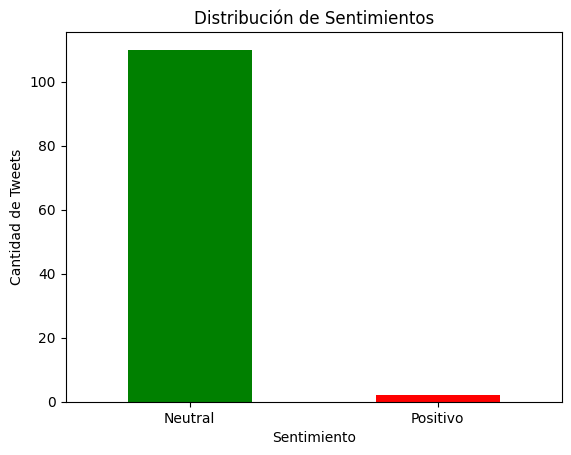

In [14]:
import matplotlib.pyplot as plt
import pandas as pd

# Assuming 'df' is your DataFrame with a 'Sentimiento' column

# Count the occurrences of each sentiment
sentiment_counts = df['Sentimiento'].value_counts()

# Create the bar chart
sentiment_counts.plot(kind='bar', color=['green', 'red', 'blue'])

# Customize the chart
plt.title('Distribución de Sentimientos')
plt.xlabel('Sentimiento')
plt.ylabel('Cantidad de Tweets')
plt.xticks(rotation=0)  # Keep x-axis labels horizontal

# Display the chart
plt.show()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


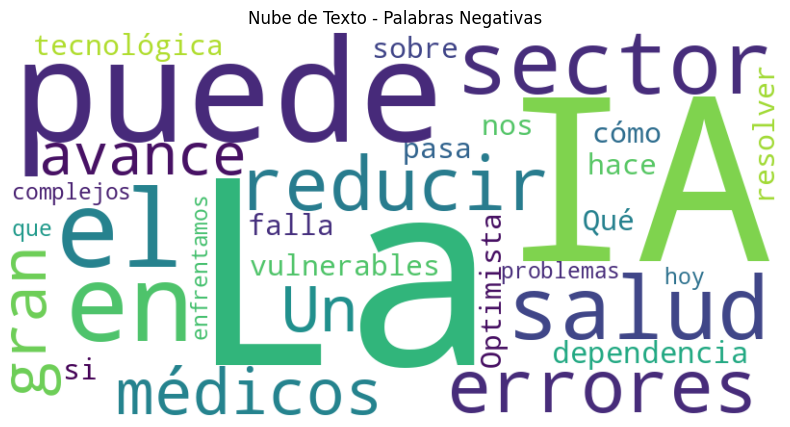

In [59]:
import matplotlib.pyplot as plt
import pandas as pd
from wordcloud import WordCloud, STOPWORDS
from google.colab import drive  # Import for Google Colab

# Mount Google Drive
drive.mount('/content/drive')

def nube_texto_negativo(file_path):
    """
    Genera una nube de texto con palabras negativas de la columna 'Tweet'
    desde un archivo CSV en Google Drive, analizando el texto directamente.
    """
    try:
        df = pd.read_csv(file_path)  # Read the CSV file

        if 'Tweet' in df.columns:
            # Define a list of negative words (customize as needed)
            palabras_negativas = ["mal", "pésimo", "terrible", "horrible", "error", "problema", "falla",  # ... add more words
                                  "decepcionado", "enojado", "triste", "frustrante"]

            # Function to check if a tweet contains negative words
            def tiene_palabras_negativas(tweet):
                return any(palabra in tweet.lower() for palabra in palabras_negativas)

            # Filter tweets containing negative words
            tweets_negativos = df[df['Tweet'].apply(tiene_palabras_negativas)]['Tweet'].astype(str).tolist()

            # Create word cloud for negative words
            negative_text = " ".join(tweets_negativos)
            stopwords = set(STOPWORDS)
            wordcloud = WordCloud(width=800, height=400, background_color='white', stopwords=stopwords).generate(negative_text)

            plt.figure(figsize=(10, 5))
            plt.imshow(wordcloud, interpolation='bilinear')
            plt.axis("off")
            plt.title("Nube de Texto - Palabras Negativas")
            plt.show()
        else:
            print("\nLa columna 'Tweet' no se encuentra en el DataFrame.")

    except FileNotFoundError:
        print(f"Error: El archivo '{file_path}' no se encontró en Google Drive.")

# Replace with the actual path to your tweet.csv file in Google Drive
file_path = '/content/drive/My Drive/tweets.csv'
nube_texto_negativo(file_path)

# --- PandasAI Asistente ---
Adicional podrás realizar preguntas personalizadas sobre el dataset con este chatbot conversacional

Escribe tu pregunta (o 'salir'): Dame 3 mensajes mas positivos y 3 mas negativos
                                   Positive Messages  \
0  Los empleos tradicionales están en riesgo. Es ...   
1  La eficiencia que aporta la IA puede llevar a ...   
2  Las startups de IA están generando muchos empl...   

                                   Negative Messages  
0  La automatización nos liberará de tareas repet...  
1  No confío en que las máquinas hagan el trabajo...  
2  La automatización nos liberará de tareas repet...  
                                   Positive Messages  \
0  Los empleos tradicionales están en riesgo. Es ...   
1  La eficiencia que aporta la IA puede llevar a ...   
2  Las startups de IA están generando muchos empl...   

                                   Negative Messages  
0  La automatización nos liberará de tareas repet...  
1  No confío en que las máquinas hagan el trabajo...  
2  La automatización nos liberará de tareas repet...  
Escribe tu pregunta (o 'salir

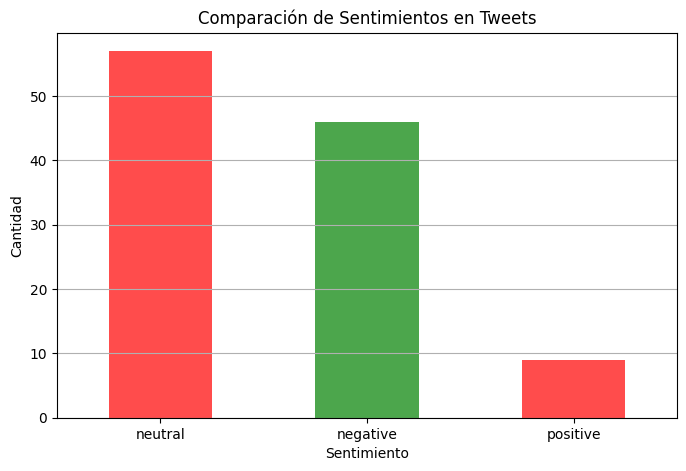

In [23]:
from pandasai import SmartDataframe
from pandasai.llm.openai import OpenAI
import pandas as pd
from google.colab import drive
from google.colab import auth
from oauth2client.client import GoogleCredentials
import os
import matplotlib.pyplot as plt  # Import matplotlib

# Authenticate and mount Google Drive
# ... (rest of the authentication and data loading code)

# ... (OpenAI API setup)

# Pass the 'df' DataFrame to SmartDataframe
pandas_ai = SmartDataframe(df, config={'llm': llm})

while True:
    pregunta = input("Escribe tu pregunta (o 'salir'): ")
    if pregunta.lower() == 'salir':
        break
    try:
        respuesta = pandas_ai.chat(pregunta)

        # Check if the response is a string (likely containing plot code)
        if isinstance(respuesta, str) and "plt.plot" in respuesta or "plt.show" in respuesta:
            # Execute the code to generate the plot
            exec(respuesta)
            # Display the plot using plt.show()
            plt.show()
        else:
            print(respuesta)  # Print other types of responses

    except Exception as e:
        print(f"Error: {e}")